# MDR-TS v19.2.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v19.2.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_9.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Playing around with feature sets

## 0. Imports

In [2]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

import torch

project_root = os.path.abspath("../../../../../") # fuck
if project_root not in sys.path:
    sys.path.append(project_root)

from d_models.Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [3]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [4]:
VERSION = "v19"
SUBVERSION = "v19.2.1"
RUN_NAME = "mdr_ts_v19_2_1"

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand  / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing \"data\"")

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
SPLIT_ROOT = DATA_ROOT / "splits"
OUTPUT_ROOT = PROJECT_ROOT / "unlogged_output" / VERSION / SUBVERSION

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:", DATA_ROOT.exists())
print("  splits exists:", SPLIT_ROOT.exists())
print("  output exists:", OUTPUT_ROOT.exists())


Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/unlogged_output/v19/v19.2.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [5]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "archive/derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "archive/derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "archive/derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/data/splits/archive/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/data/splits/archive/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/data/splits/archive/derived_8.0/test.csv


In [6]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [7]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_ema_G_API_kobs7',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
    ]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 38
  Target:   soil_moisture_5cm


In [8]:
corr = train_df[FEATURE_COLS].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# find pairs > 0.995 correlation
high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.995
]

print("Highly correlated pairs:")
for a, b, c in high_corr:
    print(f"{a} <-> {b} : {c:.5f}")

Highly correlated pairs:
V_rollmean_G_API_kobs7 <-> V_ema_G_API_kobs7 : 0.99727


In [9]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics):
    print(f"{'METRIC':<15} | {'VALUE':<10}")
    print("-" * 28)
    for k, v in metrics.items():
        val_str = f"{v:,}" if isinstance(v, int) else f"{v:+.5f}"
        print(f"{k:<15} | {val_str:<10}")

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [10]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [11]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

trainval_df_d["date"] = pd.to_datetime(trainval_df_d["date"], errors="coerce")
trainval_df_d["year"] = trainval_df_d["date"].dt.year.astype(float)

max_year = trainval_df_d["year"].max()
beta = 0.2

w_trainval = np.exp(beta * (trainval_df_d["year"] - max_year))
w_trainval = w_trainval / w_trainval.mean()

In [12]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval_d = trainval_df_d[FEATURE_COLS].copy()
y_trainval_d = trainval_df_d[TARGET_COL].copy()

X_test_d = test_df[FEATURE_COLS].copy()
y_test_d = test_df[TARGET_COL].copy()

print("\nDRIFT matrices:")
print("  X_trainval_d:", X_trainval_d.shape)
print("  X_test_d:    ", X_test_d.shape)


DRIFT matrices:
  X_trainval_d: (9588, 38)
  X_test_d:     (4016, 38)


### Drift Model (No Weights)

In [13]:
XGB_PARAMS_DRIFT_NO_W = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

In [14]:
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

xgb_drift_no_w_tv = XGBRegressor(**XGB_PARAMS_DRIFT_NO_W)
xgb_drift_no_w_tv.fit(
  trainval_df_d[FEATURE_COLS],
  trainval_df_d[TARGET_COL],
  verbose=0,
  )

y_test_d_no_w = np.asarray(test_df[TARGET_COL]).ravel()
pred_drift_test_no_w = np.asarray(xgb_drift_no_w_tv.predict(test_df[FEATURE_COLS])).ravel()

In [ ]:
metrics_dashboard(y_test_d_no_w, pred_drift_test_no_w, name="XGBoost Temporal Performance (Test Set 2023-2025)", return_dict=False)

In [16]:
print("===== NON-WEIGHTED MODEL METRICS =====")
neat_print(get_metrics_dict(y_test_d, pred_drift_test_no_w, prefix="no_w_"))

===== NON-WEIGHTED MODEL METRICS =====
METRIC          | VALUE     
----------------------------
no_w_n          | 4,016     
no_w_r2         | +0.81418  
no_w_mae        | +0.03039  
no_w_rmse       | +0.04059  
no_w_ubrmse     | +0.04049  
no_w_bias       | -0.00284  
no_w_med_ae     | +0.02369  
no_w_p90_ae     | +0.06337  
no_w_q05_err    | -0.07006  
no_w_q50_err    | -0.00325  
no_w_q95_err    | +0.05743  


### Drift Model (With Weights)

In [17]:
XGB_PARAMS_DRIFT_W = dict(
    objective="reg:pseudohubererror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

In [18]:
w_trainval_s = pd.Series(w_trainval)
years_tv = trainval_df_d["year"].reset_index(drop=True)

print("Weight stats:")
print(w_trainval_s.describe())

min_year = years_tv.min()
max_year = years_tv.max()

print("Min year weight:", float(w_trainval_s[years_tv == min_year].mean()))
print("Max year weight:", float(w_trainval_s[years_tv == max_year].mean()))

Weight stats:
count    9588.000000
mean        1.000000
std         0.336108
min         0.591030
25%         0.721885
50%         0.881713
75%         1.315361
max         1.606585
Name: year, dtype: float64
Min year weight: 0.5910295759572686
Max year weight: 1.6065849564064987


In [19]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

xgb_drift_w_tv = XGBRegressor(**XGB_PARAMS_DRIFT_W)
xgb_drift_w_tv.fit(
  trainval_df_d[FEATURE_COLS],
  trainval_df_d[TARGET_COL],
  verbose=0,
  sample_weight=w_trainval
  )

y_test_d_w = np.asarray(test_df[TARGET_COL]).ravel()
pred_drift_test_w = np.asarray(xgb_drift_w_tv.predict(test_df[FEATURE_COLS])).ravel()

In [ ]:
metrics_dashboard(y_test_d_w, pred_drift_test_w, name="XGBoost Temporal Performance (Test Set 2023-2025)", return_dict=False)

None


In [ ]:
print("======= WEIGHTED MODEL METRICS =======")
neat_print(get_metrics_dict(y_test_d, pred_drift_test_w, prefix="no_w_"))

======= WEIGHTED MODEL METRICS =======
METRIC          | VALUE     
----------------------------
no_w_n          | 4,016     
no_w_r2         | +0.82239  
no_w_mae        | +0.02832  
no_w_rmse       | +0.03968  
no_w_ubrmse     | +0.03956  
no_w_bias       | -0.00320  
no_w_med_ae     | +0.02032  
no_w_p90_ae     | +0.06152  
no_w_q05_err    | -0.06826  
no_w_q50_err    | -0.00285  
no_w_q95_err    | +0.05462  


In [ ]:
diag_d = test_df.copy().reset_index(drop=True)
diag_d["year"] = pd.to_datetime(diag_d["date"], errors="coerce").dt.year
diag_d["y"] = y_test_d
diag_d["pred"] = pred_drift_test_w

d2023 = diag_d[diag_d["year"] == 2023].copy()

if len(d2023) >= 2:
    r2_2023 = float(r2_score(d2023["y"], d2023["pred"]))
    a, b = np.polyfit(d2023["pred"], d2023["y"], 1)  # y ≈ a*pred + b
    print("\nDRIFT 2023 R2:", r2_2023)
    print("DRIFT 2023 slope:", float(a), "intercept:", float(b))
else:
    print("\nNo 2023 rows found in DRIFT test slice.")


DRIFT 2023 R2: 0.8027184313847062
DRIFT 2023 slope: 0.9194130190612515 intercept: 0.016916230770106833


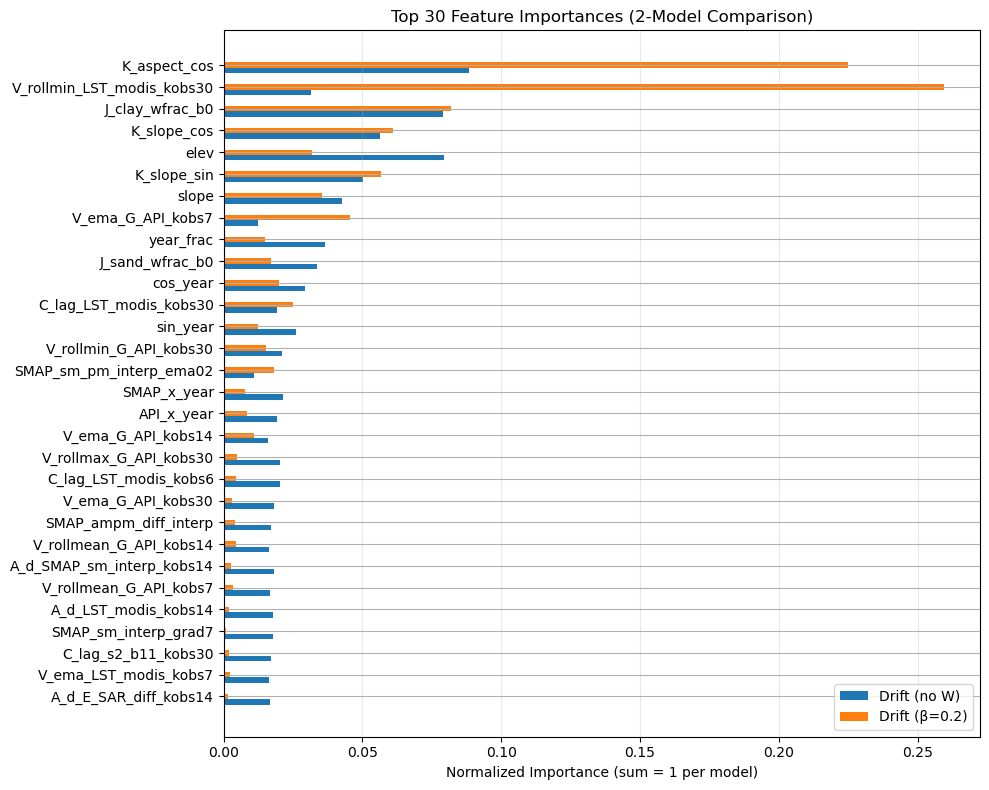

In [ ]:
def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp = imp / imp.sum()
    return imp

imp_no_w = get_xgb_importance(xgb_drift_no_w_tv, FEATURE_COLS)
imp_w    = get_xgb_importance(xgb_drift_w_tv, FEATURE_COLS)

all_feats = sorted(set(imp_no_w.index) | set(imp_w.index))

cmp = pd.DataFrame({
    "drift_no_w": imp_no_w.reindex(all_feats, fill_value=0.0),
    "drift_w":    imp_w.reindex(all_feats, fill_value=0.0),
})

cmp["consensus_mean"] = cmp.mean(axis=1)

TOP_K = 30
cmp_top = cmp.sort_values("consensus_mean", ascending=False).head(TOP_K)

cmp_top_sorted = cmp_top.sort_values("consensus_mean", ascending=True)
plot_df = cmp_top_sorted[["drift_no_w", "drift_w"]]

plt.figure(figsize=(10, 8))
y = np.arange(len(plot_df))

plt.barh(y - 0.25, plot_df["drift_no_w"].values, height=0.25, label="Drift (no W)")
plt.barh(y,         plot_df["drift_w"].values,    height=0.25, label="Drift (β=0.2)")

plt.yticks(y, plot_df.index)
plt.xlabel("Normalized Importance (sum = 1 per model)")
plt.title(f"Top {TOP_K} Feature Importances (2-Model Comparison)")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
display(cmp_top)

,drift_no_w,drift_w,consensus_mean
K_aspect_cos,0.088497,0.224794,0.156646
V_rollmin_LST_modis_kobs30,0.031330,0.259513,0.145421
J_clay_wfrac_b0,0.078912,0.082061,0.080487
K_slope_cos,0.056433,0.060849,0.058641
elev,0.079519,0.031702,0.055611
K_slope_sin,0.050145,0.056797,0.053471
slope,0.042586,0.035385,0.038985
V_ema_G_API_kobs7,0.012562,0.045600,0.029081
year_frac,0.036658,0.014778,0.025718
J_sand_wfrac_b0,0.033696,0.017247,0.025471


### Residuals

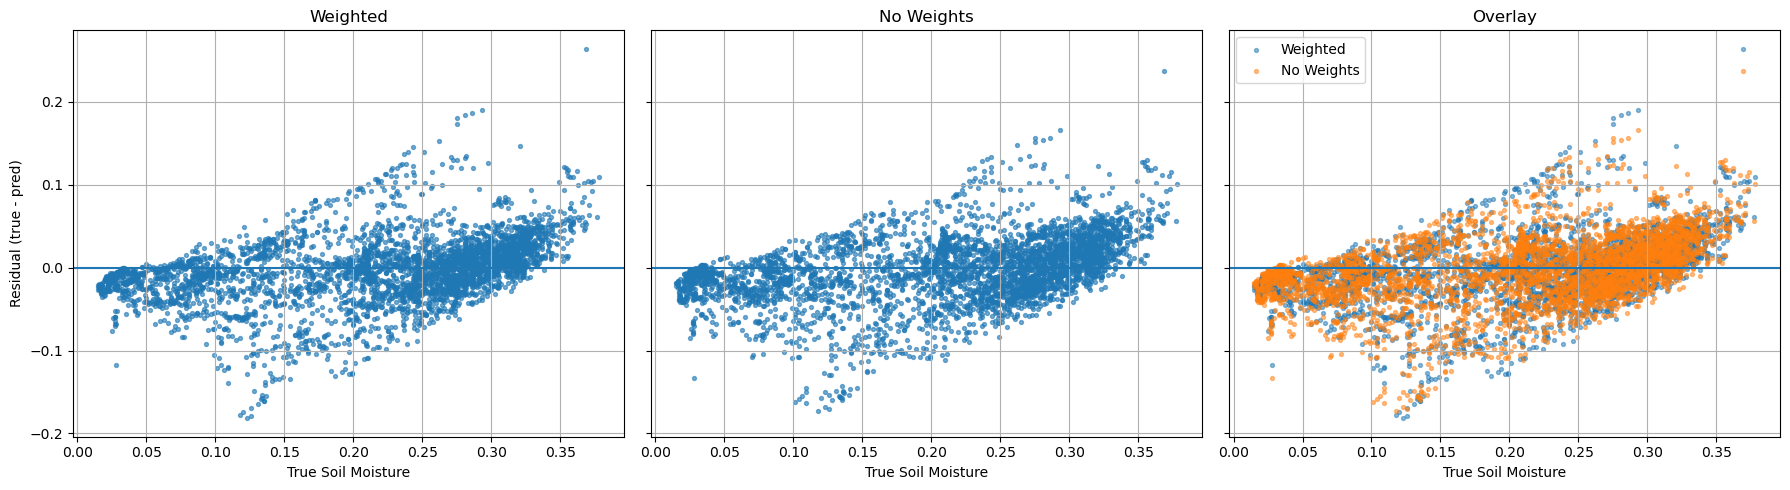

In [ ]:
res_w   = y_test_d - pred_drift_test_w
res_nw  = y_test_d - pred_drift_test_no_w

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(y_test_d, res_w, s=8, alpha=0.6)
axes[0].axhline(0)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title("Weighted")

axes[1].scatter(y_test_d, res_nw, s=8, alpha=0.6)
axes[1].axhline(0)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_title("No Weights")

axes[2].scatter(y_test_d, res_w,  s=8, alpha=0.5, label="Weighted")
axes[2].scatter(y_test_d, res_nw, s=8, alpha=0.5, label="No Weights")
axes[2].axhline(0)
axes[2].set_xlabel("True Soil Moisture")
axes[2].set_title("Overlay")
axes[2].legend()

plt.tight_layout()
plt.show()

---

_Jakob Balkovec_

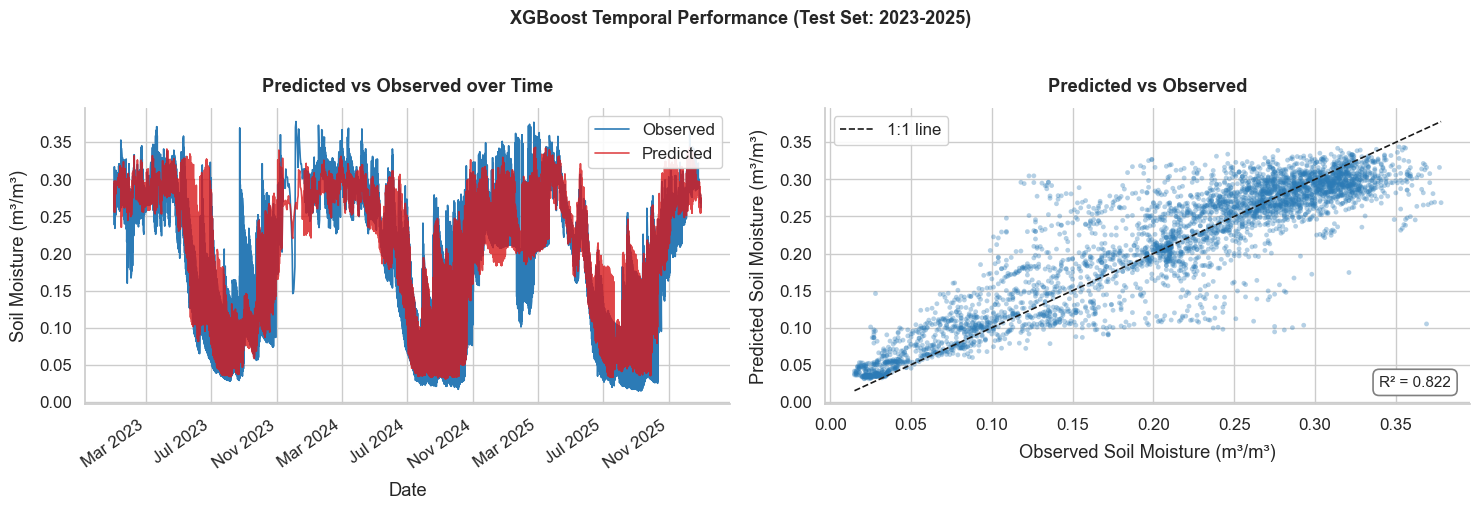

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

dates_test = pd.to_datetime(test_df["date"], errors="coerce")
r2 = r2_score(y_test_d_w, pred_drift_test_w)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Subplot 1: Time series ---
ax1 = axes[0]
ax1.plot(dates_test, y_test_d_w, label="Observed", color="#2C7BB6", linewidth=1.2)
ax1.plot(dates_test, pred_drift_test_w, label="Predicted", color="#D7191C", linewidth=1.2, alpha=0.8)
ax1.set_xlabel("Date", labelpad=8)
ax1.set_ylabel("Soil Moisture (m³/m³)", labelpad=8)
ax1.set_title("Predicted vs Observed over Time", fontweight="bold", pad=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=35, ha="right")
ax1.legend(frameon=True, framealpha=0.9)
sns.despine(ax=ax1)

# --- Subplot 2: Scatter ---
ax2 = axes[1]
sns.scatterplot(
    x=y_test_d_w,
    y=pred_drift_test_w,
    ax=ax2,
    alpha=0.35,
    s=12,
    color="#2C7BB6",
    edgecolor="none"
)
lims = [
    min(y_test_d_w.min(), pred_drift_test_w.min()),
    max(y_test_d_w.max(), pred_drift_test_w.max())
]
ax2.plot(lims, lims, "k--", linewidth=1.2, label="1:1 line")
ax2.set_xlabel("Observed Soil Moisture (m³/m³)", labelpad=8)
ax2.set_ylabel("Predicted Soil Moisture (m³/m³)", labelpad=8)
ax2.set_title("Predicted vs Observed", fontweight="bold", pad=12)
ax2.legend(frameon=True, framealpha=0.9)
ax2.annotate(
    f"R² = {r2:.3f}",
    xy=(0.97, 0.05),
    xycoords="axes fraction",
    fontsize=11,
    ha="right",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", linewidth=1.2)

)
sns.despine(ax=ax2)

plt.suptitle("XGBoost Temporal Performance (Test Set: 2023-2025)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# --- Temporal R² per station (from your existing test predictions) ---
test_df_plot = test_df.copy()
test_df_plot["pred"] = pred_drift_test_w
test_df_plot["actual"] = y_test_d_w

temporal_r2 = (
    test_df_plot
    .groupby("station_id")
    .apply(lambda g: r2_score(g["actual"], g["pred"]))
    .reset_index()
    .rename(columns={0: "r2", "station": "Station"})
)
temporal_r2["Type"] = "Temporal"

# --- Spatial R² per station (LOSO -- train on 4, test on held-out 1) ---
spatial_r2_rows = []
stations = test_df["station_id"].unique()  # or use your full df if LOSO uses all data

full_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

for held_out in stations:
    train_loso = full_df[full_df["station_id"] != held_out]
    test_loso  = full_df[full_df["station_id"] == held_out]

    X_train_l = train_loso[FEATURE_COLS]
    y_train_l = train_loso[TARGET_COL]
    X_test_l  = test_loso[FEATURE_COLS]
    y_test_l  = test_loso[TARGET_COL]

    model_loso = XGBRegressor(**XGB_PARAMS_DRIFT_W)
    model_loso.fit(X_train_l, y_train_l, verbose=0)

    pred_l = model_loso.predict(X_test_l)
    r2_l   = r2_score(y_test_l, pred_l)

    spatial_r2_rows.append({"Station": held_out, "r2": r2_l, "Type": "Spatial"})

spatial_r2 = pd.DataFrame(spatial_r2_rows)

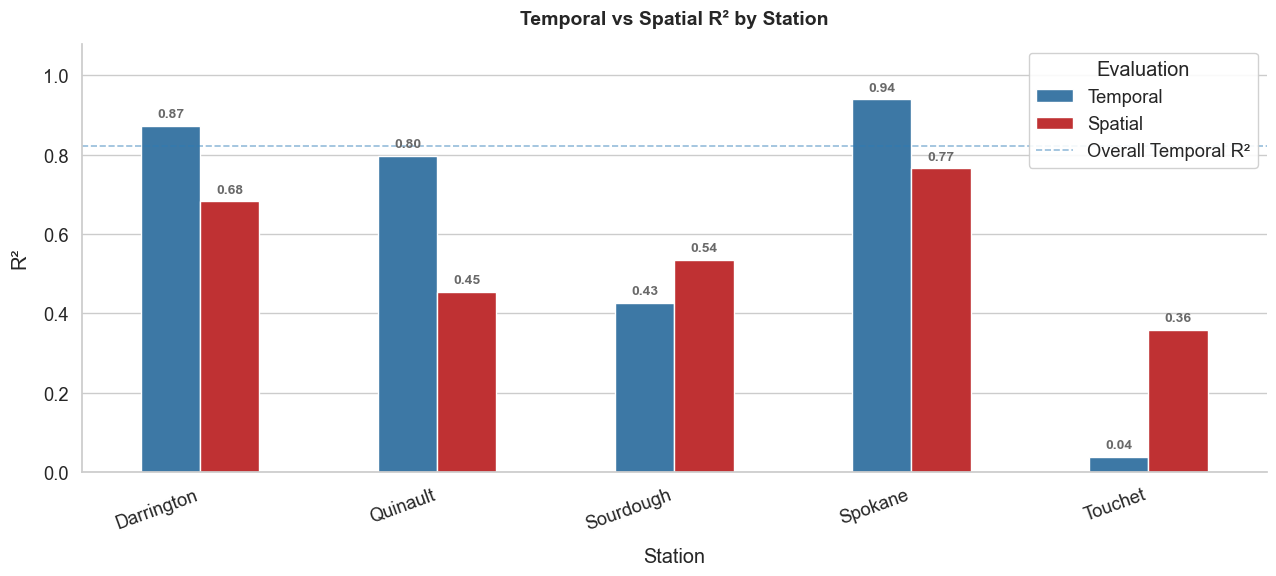

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(
    data=combined,
    x="Station",
    y="r2",
    hue="Type",
    palette={"Temporal": "#2C7BB6", "Spatial": "#D7191C"},
    ax=ax,
    dodge=True,          # <-- this is the key
    width=0.5,
    edgecolor="white",
    linewidth=1.0,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4,
        fontsize=10,
        fontweight="bold",
        color="dimgray"
    )

ax.axhline(0.822, color="#2C7BB6", linestyle="--", linewidth=1.2, alpha=0.5, label="Overall Temporal R²")
ax.set_xlabel("Station", labelpad=10)
ax.set_ylabel("R²", labelpad=10)
ax.set_title("Temporal vs Spatial R² by Station", fontweight="bold", pad=14, fontsize=14)
ax.set_ylim(0, 1.08)
ax.legend(title="Evaluation", frameon=True, framealpha=0.9, loc="upper right")
plt.xticks(rotation=20, ha="right")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("r2_per_station.png", dpi=150, bbox_inches="tight")
plt.show()